# 06 Time Series Forecasting

## Introduction

Weather forecasting is inherently a time series prediction problem in which future atmospheric conditions are estimated using historical observations recorded over time. Unlike traditional supervised machine learning, time series forecasting must preserve the chronological ordering of observations to ensure that future information is never used during model training.

This notebook develops a forecasting pipeline for a single geographical location by selecting a continuous weather time series, engineering temporal features, applying chronological validation techniques, and evaluating forecasting models capable of predicting future air temperature.

# Objectives

The objectives of this notebook are to:

- Select a single weather station for forecasting.
- Preserve chronological ordering of observations.
- Engineer temporal forecasting features.
- Perform chronological train-test splitting.
- Apply TimeSeriesSplit cross-validation.
- Train forecasting models.
- Evaluate forecasting performance.
- Save the final forecasting model.

# 3. Import Libraries

## Objective

Import the Python libraries and project modules required for time series forecasting.

In [1]:
import sys
from pathlib import Path

# Add the project root to Python path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [3]:
print("Libraries imported successfully.")

Libraries imported successfully.


The required scientific computing, visualization, and machine learning libraries were successfully imported. These libraries provide the functionality needed for data manipulation, temporal validation, model development, and forecasting evaluation.

# 4. Load the Feature-Engineered Dataset

## Objective

Load the feature-engineered dataset created during Notebook 04. This dataset contains the processed weather observations that will be transformed into a chronological forecasting dataset.

In [4]:
forecast_df = pd.read_csv(
    "../data/processed/weather_engineered.csv"
)

forecast_df.head()

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,wind_mph,wind_kph,wind_degree,...,wind_direction_WNW,wind_direction_WSW,moon_phase_First Quarter,moon_phase_Full Moon,moon_phase_Last Quarter,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous
0,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,-0.579370,4.3,-0.734996,220,...,0,0,0,0,0,0,0,0,0,1
1,San Juan,9.97,-84.08,America/Costa_Rica,1715849100,2024-05-16 02:45:00,-0.047178,2.2,-1.135403,10,...,0,0,0,0,0,0,0,0,0,1
2,Mexico City,19.43,-99.13,America/Mexico_City,1715849100,2024-05-16 02:45:00,-0.068900,6.7,-0.234487,212,...,0,0,0,0,0,0,0,0,0,1
3,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,0.495874,2.2,-1.135403,182,...,0,0,0,0,0,0,0,0,0,1
4,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,-0.155789,13.6,1.166937,190,...,0,0,0,0,0,0,0,0,0,1


In [5]:
forecast_df.shape

(151827, 334)

The feature-engineered weather dataset was successfully loaded. It contains numerical variables together with encoded categorical features generated during the feature engineering stage and will serve as the basis for the forecasting workflow.

# 5. Select a Forecasting Location

## Objective

Because the dataset contains weather observations collected from multiple geographical locations, a single location must be selected before constructing a chronological forecasting dataset.

Forecasting one location at a time ensures that consecutive observations belong to the same weather station and represent a valid time series.

In [6]:
forecast_df["location_name"].value_counts().head(20)

location_name
Sanaa           782
Vatican City    781
Kyiv            781
Bujumbura       781
Malabo          781
Valletta        781
Bern            781
Dakar           781
Accra           781
Tokyo           781
Warsaw          781
Asmara          781
Suva            781
N'djamena       781
Tashkent        781
Baghdad         781
Kabul           780
Luanda          780
Madrid          780
Belgrade        780
Name: count, dtype: int64

### Select a Single Forecasting Location

A single geographical location is selected to construct a continuous weather time series. Restricting the analysis to one location ensures that consecutive observations belong to the same weather station and represent a valid forecasting problem.

In [7]:
forecast_location = "Tokyo"

forecast_df = (
    forecast_df[
        forecast_df["location_name"] == forecast_location
    ]
    .copy()
)

forecast_df.head()

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,wind_mph,wind_kph,wind_degree,...,wind_direction_WNW,wind_direction_WSW,moon_phase_First Quarter,moon_phase_Full Moon,moon_phase_Last Quarter,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous
324,Tokyo,35.69,139.69,Asia/Tokyo,1715849100,2024-05-16 17:45:00,0.278653,20.6,2.555849,200,...,0,0,0,0,0,0,0,0,0,1
373,Tokyo,35.69,139.69,Asia/Tokyo,1715868000,2024-05-16 23:00:00,-0.340427,11.9,0.804069,190,...,0,0,0,0,0,0,0,0,0,1
568,Tokyo,35.69,139.69,Asia/Tokyo,1715961600,2024-05-18 01:00:00,-0.373010,2.5,-1.085352,140,...,0,0,0,0,0,0,0,0,0,1
764,Tokyo,35.69,139.69,Asia/Tokyo,1716042600,2024-05-18 23:30:00,-0.155789,6.9,-0.184436,170,...,0,0,0,0,0,0,0,0,0,1
954,Tokyo,35.69,139.69,Asia/Tokyo,1716127200,2024-05-19 23:00:00,-0.242677,5.6,-0.459716,280,...,0,0,0,0,0,0,0,0,0,1


In [8]:
forecast_df.shape

(781, 334)

In [9]:
forecast_df["location_name"].unique()

array(['Tokyo'], dtype=object)

The forecasting dataset has been restricted to weather observations recorded in Tokyo. Each row now represents a consecutive observation from the same geographical location, allowing the construction of a valid chronological forecasting dataset.

In [10]:
forecast_df.duplicated(
    subset=["last_updated", "location_name"]
).sum()

0

### Convert Timestamp to Datetime

Convert the timestamp column into a datetime object to enable chronological ordering and time-based feature engineering.

In [11]:
forecast_df["last_updated"] = pd.to_datetime(
    forecast_df["last_updated"]
)

In [12]:
forecast_df["last_updated"].dtype

dtype('<M8[ns]')

### Sort Observations Chronologically

The observations are ordered by their timestamp so that every record follows the natural progression of time. This ordering is essential for forecasting because future observations must never precede historical observations.

In [13]:
forecast_df = (
    forecast_df
    .sort_values("last_updated")
    .reset_index(drop=True)
)

In [14]:
forecast_df[
    [
        "last_updated",
        "temperature_celsius",
    ]
].head()

,last_updated,temperature_celsius
0,2024-05-16 17:45:00,0.278653
1,2024-05-16 23:00:00,-0.340427
2,2024-05-18 01:00:00,-0.373010
3,2024-05-18 23:30:00,-0.155789
4,2024-05-19 23:00:00,-0.242677


In [15]:
forecast_df[
    [
        "last_updated",
        "temperature_celsius",
    ]
].tail()

,last_updated,temperature_celsius
776,2026-07-03 15:00:00,0.506735
777,2026-07-04 14:45:00,0.506735
778,2026-07-05 14:30:00,0.311236
779,2026-07-06 15:00:00,0.517596
780,2026-07-07 15:00:00,0.408986


The weather observations have been successfully ordered chronologically, ensuring that all subsequent forecasting steps preserve the temporal sequence of the data and avoid look-ahead bias.

# 6. Prepare the Time Series Dataset

## Objective

Transform the chronological weather observations into a supervised forecasting dataset by creating a future prediction target.

The preparation process includes:

- Creating a one-step-ahead forecasting target.
- Removing observations without future values.
- Verifying that the forecasting dataset is complete and chronologically consistent.

These steps convert the historical weather observations into a dataset suitable for supervised machine learning forecasting.

### Create the Forecasting Target

The forecasting target is defined as the temperature recorded during the next observation.

Shifting the temperature column one step into the future allows the forecasting model to learn how current weather conditions relate to future temperature.

In [17]:
forecast_df["target_temperature"] = (
    forecast_df["temperature_celsius"]
    .shift(-1)
)

In [18]:
forecast_df[
    [
        "last_updated",
        "temperature_celsius",
        "target_temperature",
    ]
].head(10)

,last_updated,temperature_celsius,target_temperature
0,2024-05-16 17:45:00,0.278653,-0.340427
1,2024-05-16 23:00:00,-0.340427,-0.373010
2,2024-05-18 01:00:00,-0.373010,-0.155789
3,2024-05-18 23:30:00,-0.155789,-0.242677
4,2024-05-19 23:00:00,-0.242677,-0.155789
5,2024-05-20 23:45:00,-0.155789,-0.090623
6,2024-05-21 23:45:00,-0.090623,-0.155789
7,2024-05-22 23:15:00,-0.155789,-0.123206
8,2024-05-23 23:00:00,-0.123206,0.104876
9,2024-05-24 23:30:00,0.104876,-0.307844


The forecasting target has been successfully created by shifting the temperature observations one step into the future. This transforms the original weather observations into a supervised forecasting problem where historical conditions are used to estimate future temperature.

### Remove Missing Forecast Targets

The final observation has no subsequent measurement and therefore cannot be used for forecasting. It is removed before model development.

In [19]:
forecast_df = (
    forecast_df
    .dropna()
    .reset_index(drop=True)
)

In [20]:
forecast_df.shape

(780, 335)

In [21]:
forecast_df["target_temperature"].isna().sum()

0

The final observation without a future target has been removed, ensuring that every remaining observation contains both historical weather information and the corresponding future temperature used for supervised forecasting.

In [22]:
forecast_df[
    [
        "last_updated",
        "temperature_celsius",
        "target_temperature",
    ]
].tail()

,last_updated,temperature_celsius,target_temperature
775,2026-07-02 14:45:00,0.083154,0.506735
776,2026-07-03 15:00:00,0.506735,0.506735
777,2026-07-04 14:45:00,0.506735,0.311236
778,2026-07-05 14:30:00,0.311236,0.517596
779,2026-07-06 15:00:00,0.517596,0.408986


In [23]:
forecast_dataset = forecast_df.copy()

forecast_dataset.head()

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,wind_mph,wind_kph,wind_degree,...,wind_direction_WSW,moon_phase_First Quarter,moon_phase_Full Moon,moon_phase_Last Quarter,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous,target_temperature
0,Tokyo,35.69,139.69,Asia/Tokyo,1715849100,2024-05-16 17:45:00,0.278653,20.6,2.555849,200,...,0,0,0,0,0,0,0,0,1,-0.340427
1,Tokyo,35.69,139.69,Asia/Tokyo,1715868000,2024-05-16 23:00:00,-0.340427,11.9,0.804069,190,...,0,0,0,0,0,0,0,0,1,-0.373010
2,Tokyo,35.69,139.69,Asia/Tokyo,1715961600,2024-05-18 01:00:00,-0.373010,2.5,-1.085352,140,...,0,0,0,0,0,0,0,0,1,-0.155789
3,Tokyo,35.69,139.69,Asia/Tokyo,1716042600,2024-05-18 23:30:00,-0.155789,6.9,-0.184436,170,...,0,0,0,0,0,0,0,0,1,-0.242677
4,Tokyo,35.69,139.69,Asia/Tokyo,1716127200,2024-05-19 23:00:00,-0.242677,5.6,-0.459716,280,...,0,0,0,0,0,0,0,0,1,-0.155789


In [24]:
forecast_dataset.shape

(780, 335)

The forecasting dataset is now complete. Each observation contains historical weather measurements together with the corresponding future temperature that the forecasting models will learn to predict.

## Section Summary

The chronological weather observations were successfully transformed into a supervised forecasting dataset.

Key preparation steps included:

- Creating a one-step-ahead forecasting target.
- Removing observations without future targets.
- Verifying chronological consistency.
- Constructing the final forecasting dataset for subsequent temporal feature engineering.

The dataset is now ready for generating lag-based forecasting features.

# 7. Time-Based Feature Engineering

## Objective

Engineer temporal features that capture historical weather behavior while preserving chronological integrity.

The engineered features include:

- Lag features
- Rolling statistics
- Calendar-based features

These variables provide historical context that enables forecasting models to learn temporal dependencies without introducing future information.

### Create Lag Features

Lag features represent previous observations of the target variable.

For example:

- Lag 1 = previous temperature
- Lag 2 = temperature two observations ago
- Lag 3 = temperature three observations ago

These features allow the forecasting model to learn temporal dependencies between consecutive observations.

In [25]:
forecast_dataset["temp_lag_1"] = (
    forecast_dataset["temperature_celsius"]
    .shift(1)
)

forecast_dataset["temp_lag_2"] = (
    forecast_dataset["temperature_celsius"]
    .shift(2)
)

forecast_dataset["temp_lag_3"] = (
    forecast_dataset["temperature_celsius"]
    .shift(3)
)

In [26]:
forecast_dataset[
    [
        "temperature_celsius",
        "temp_lag_1",
        "temp_lag_2",
        "temp_lag_3",
    ]
].head(10)

,temperature_celsius,temp_lag_1,temp_lag_2,temp_lag_3
0,0.278653,NaN,NaN,NaN
1,-0.340427,0.278653,NaN,NaN
2,-0.373010,-0.340427,0.278653,NaN
3,-0.155789,-0.373010,-0.340427,0.278653
4,-0.242677,-0.155789,-0.373010,-0.340427
5,-0.155789,-0.242677,-0.155789,-0.373010
6,-0.090623,-0.155789,-0.242677,-0.155789
7,-0.155789,-0.090623,-0.155789,-0.242677
8,-0.123206,-0.155789,-0.090623,-0.155789
9,0.104876,-0.123206,-0.155789,-0.090623


Lag features introduce historical temperature information into the forecasting dataset. They provide the model with recent observations that are often highly informative for predicting future weather conditions.

### Rolling Mean

The rolling mean computes the average temperature across the previous observations.

Rolling averages smooth short-term fluctuations while preserving longer-term temperature trends.

In [27]:
forecast_dataset["rolling_mean_3"] = (
    forecast_dataset["temperature_celsius"]
    .rolling(window=3)
    .mean()
)

In [28]:
forecast_dataset[
    [
        "temperature_celsius",
        "rolling_mean_3",
    ]
].head(10)

,temperature_celsius,rolling_mean_3
0,0.278653,NaN
1,-0.340427,NaN
2,-0.373010,-0.144928
3,-0.155789,-0.289742
4,-0.242677,-0.257159
5,-0.155789,-0.184752
6,-0.090623,-0.163030
7,-0.155789,-0.134067
8,-0.123206,-0.123206
9,0.104876,-0.058039


### Rolling Standard Deviation

The rolling standard deviation measures recent temperature variability.

Periods with rapidly changing temperatures typically produce higher rolling standard deviations than relatively stable weather periods.

In [29]:
forecast_dataset["rolling_std_3"] = (
    forecast_dataset["temperature_celsius"]
    .rolling(window=3)
    .std()
)

In [30]:
forecast_dataset[
    [
        "temperature_celsius",
        "rolling_std_3",
    ]
].head(10)

,temperature_celsius,rolling_std_3
0,0.278653,NaN
1,-0.340427,NaN
2,-0.373010,0.367193
3,-0.155789,0.117145
4,-0.242677,0.109332
5,-0.155789,0.050165
6,-0.090623,0.076286
7,-0.155789,0.037624
8,-0.123206,0.032583
9,0.104876,0.142027


### Calendar Features

Extract temporal information directly from the timestamp.

These variables help the forecasting model identify recurring daily, weekly, and seasonal weather patterns.

In [31]:
forecast_dataset["hour"] = (
    forecast_dataset["last_updated"]
    .dt.hour
)

forecast_dataset["day"] = (
    forecast_dataset["last_updated"]
    .dt.day
)

forecast_dataset["day_of_week"] = (
    forecast_dataset["last_updated"]
    .dt.dayofweek
)

forecast_dataset["month"] = (
    forecast_dataset["last_updated"]
    .dt.month
)

forecast_dataset["year"] = (
    forecast_dataset["last_updated"]
    .dt.year
)

In [32]:
forecast_dataset[
    [
        "last_updated",
        "hour",
        "day",
        "day_of_week",
        "month",
        "year",
    ]
].head()

,last_updated,hour,day,day_of_week,month,year
0,2024-05-16 17:45:00,17,16,3,5,2024
1,2024-05-16 23:00:00,23,16,3,5,2024
2,2024-05-18 01:00:00,1,18,5,5,2024
3,2024-05-18 23:30:00,23,18,5,5,2024
4,2024-05-19 23:00:00,23,19,6,5,2024


### Remove Missing Observations

Lag features and rolling statistics cannot be computed for the earliest observations because insufficient historical information exists.

These incomplete observations are removed before model development.

In [33]:
forecast_dataset = (
    forecast_dataset
    .dropna()
    .reset_index(drop=True)
)

In [34]:
forecast_dataset.shape

(777, 340)

In [35]:
forecast_dataset.isna().sum().sum()

0

In [36]:
forecast_dataset.head()

,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,wind_mph,wind_kph,wind_degree,...,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous,target_temperature,temp_lag_1,temp_lag_2,temp_lag_3,rolling_mean_3,rolling_std_3
0,Tokyo,35.69,139.69,Asia/Tokyo,1716042600,2024-05-18 23:30:00,-0.155789,6.9,-0.184436,170,...,0,0,0,1,-0.242677,-0.373010,-0.340427,0.278653,-0.289742,0.117145
1,Tokyo,35.69,139.69,Asia/Tokyo,1716127200,2024-05-19 23:00:00,-0.242677,5.6,-0.459716,280,...,0,0,0,1,-0.155789,-0.155789,-0.373010,-0.340427,-0.257159,0.109332
2,Tokyo,35.69,139.69,Asia/Tokyo,1716216300,2024-05-20 23:45:00,-0.155789,2.2,-1.135403,198,...,0,0,0,1,-0.090623,-0.242677,-0.155789,-0.373010,-0.184752,0.050165
3,Tokyo,35.69,139.69,Asia/Tokyo,1716302700,2024-05-21 23:45:00,-0.090623,10.5,0.528789,150,...,0,0,0,1,-0.155789,-0.155789,-0.242677,-0.155789,-0.163030,0.076286
4,Tokyo,35.69,139.69,Asia/Tokyo,1716387300,2024-05-22 23:15:00,-0.155789,10.5,0.528789,180,...,0,0,0,1,-0.123206,-0.090623,-0.155789,-0.242677,-0.134067,0.037624


In [37]:
forecast_dataset[
    [
        "temperature_celsius",
        "temp_lag_1",
        "temp_lag_2",
        "temp_lag_3",
        "rolling_mean_3",
        "rolling_std_3",
        "hour",
        "day",
        "day_of_week",
        "month",
        "target_temperature",
    ]
].head(10)

,temperature_celsius,temp_lag_1,temp_lag_2,temp_lag_3,rolling_mean_3,rolling_std_3,hour,day,day_of_week,month,target_temperature
0,-0.155789,-0.373010,-0.340427,0.278653,-0.289742,0.117145,23,18,5,5,-0.242677
1,-0.242677,-0.155789,-0.373010,-0.340427,-0.257159,0.109332,23,19,6,5,-0.155789
2,-0.155789,-0.242677,-0.155789,-0.373010,-0.184752,0.050165,23,20,0,5,-0.090623
3,-0.090623,-0.155789,-0.242677,-0.155789,-0.163030,0.076286,23,21,1,5,-0.155789
4,-0.155789,-0.090623,-0.155789,-0.242677,-0.134067,0.037624,23,22,2,5,-0.123206
5,-0.123206,-0.155789,-0.090623,-0.155789,-0.123206,0.032583,23,23,3,5,0.104876
6,0.104876,-0.123206,-0.155789,-0.090623,-0.058039,0.142027,23,24,4,5,-0.307844
7,-0.307844,0.104876,-0.123206,-0.155789,-0.108724,0.206741,23,25,5,5,-0.047178
8,-0.047178,-0.307844,0.104876,-0.123206,-0.083382,0.208728,23,26,6,5,0.028849
9,0.028849,-0.047178,-0.307844,0.104876,-0.108724,0.176583,23,27,0,5,0.148321


The forecasting dataset has been enriched with multiple temporal features describing recent weather history and calendar information.

Lag variables capture short-term temporal dependencies, rolling statistics summarize recent weather behavior, and calendar features represent recurring daily and seasonal patterns. Together, these engineered features provide the forecasting models with substantially more temporal context than the original observations alone.

## Section Summary

The time series dataset has been successfully enhanced through temporal feature engineering.

The following forecasting features were created:

- Three lag variables
- Rolling mean
- Rolling standard deviation
- Calendar features (hour, day, weekday, month, year)

These variables provide historical context while preserving chronological integrity and avoiding look-ahead bias, preparing the dataset for chronological model training and evaluation.

# 8. Chronological Train-Test Split

## Objective

Split the forecasting dataset into training and testing subsets while preserving the chronological ordering of observations.

Unlike traditional supervised machine learning, time series forecasting requires that historical observations are used to predict future observations. Therefore, random shuffling is avoided to prevent information leakage from future data.

### Select Features and Target

Separate the predictor variables from the forecasting target.

The target variable represents the temperature at the next observation, while the predictor variables contain the current weather measurements together with the engineered temporal features.

In [38]:
excluded_columns = [
    "target_temperature",
    "last_updated",
]

X = forecast_dataset.drop(columns=excluded_columns)

y = forecast_dataset["target_temperature"]

In [39]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (777, 338)
Target Shape: (777,)


The predictor matrix contains the engineered weather and temporal features, while the target variable corresponds to the air temperature recorded at the subsequent observation.

### Chronological Train-Test Split

The forecasting dataset is divided chronologically so that the model is trained using historical observations and evaluated using future observations.

This approach accurately reflects real-world forecasting scenarios and eliminates look-ahead bias.

In [40]:
split_index = int(len(forecast_dataset) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [41]:
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 621
Testing Samples  : 156


In [42]:
forecast_dataset.iloc[:split_index][
    "last_updated"
].agg(["min", "max"])

min   2024-05-18 23:30:00
max   2026-01-31 16:00:00
Name: last_updated, dtype: datetime64[ns]

In [43]:
forecast_dataset.iloc[split_index:][
    "last_updated"
].agg(["min", "max"])

min   2026-02-01 16:00:00
max   2026-07-06 15:00:00
Name: last_updated, dtype: datetime64[ns]

The chronological split successfully separates historical observations from future observations. This evaluation strategy mirrors real forecasting applications in which future weather conditions are predicted using only information available from the past.

In [44]:
print("Training Features")
display(X_train.head())

print("Testing Features")
display(X_test.head())

Training Features


,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,wind_mph,wind_kph,wind_degree,pressure_mb,...,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous,temp_lag_1,temp_lag_2,temp_lag_3,rolling_mean_3,rolling_std_3
0,Tokyo,35.69,139.69,Asia/Tokyo,1716042600,-0.155789,6.9,-0.184436,170,0.606017,...,0,0,0,0,1,-0.373010,-0.340427,0.278653,-0.289742,0.117145
1,Tokyo,35.69,139.69,Asia/Tokyo,1716127200,-0.242677,5.6,-0.459716,280,0.606017,...,0,0,0,0,1,-0.155789,-0.373010,-0.340427,-0.257159,0.109332
2,Tokyo,35.69,139.69,Asia/Tokyo,1716216300,-0.155789,2.2,-1.135403,198,-0.315289,...,0,0,0,0,1,-0.242677,-0.155789,-0.373010,-0.184752,0.050165
3,Tokyo,35.69,139.69,Asia/Tokyo,1716302700,-0.090623,10.5,0.528789,150,0.759569,...,0,0,0,0,1,-0.155789,-0.242677,-0.155789,-0.163030,0.076286
4,Tokyo,35.69,139.69,Asia/Tokyo,1716387300,-0.155789,10.5,0.528789,180,0.452466,...,0,0,0,0,1,-0.090623,-0.155789,-0.242677,-0.134067,0.037624


Testing Features


,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,wind_mph,wind_kph,wind_degree,pressure_mb,...,moon_phase_New Moon,moon_phase_Waning Crescent,moon_phase_Waning Gibbous,moon_phase_Waxing Crescent,moon_phase_Waxing Gibbous,temp_lag_1,temp_lag_2,temp_lag_3,rolling_mean_3,rolling_std_3
621,Tokyo,35.6895,139.6917,Asia/Tokyo,1769929200,-1.209311,3.6,-0.860123,68,-0.161738,...,0,0,0,0,1,-1.350504,-1.415671,-1.546003,-1.325162,0.105488
622,Tokyo,35.6895,139.6917,Asia/Tokyo,1770015600,-1.111561,2.7,-1.047814,142,-0.161738,...,0,0,0,0,0,-1.209311,-1.350504,-1.415671,-1.223792,0.120128
623,Tokyo,35.6895,139.6917,Asia/Tokyo,1770102000,-1.220172,3.8,-0.822585,5,1.066671,...,0,0,1,0,0,-1.111561,-1.209311,-1.350504,-1.180348,0.059818
624,Tokyo,35.6895,139.6917,Asia/Tokyo,1770188400,-1.122422,2.5,-1.085352,104,0.452466,...,0,0,1,0,0,-1.220172,-1.111561,-1.209311,-1.151385,0.059818
625,Tokyo,35.6895,139.6917,Asia/Tokyo,1770274800,-0.905201,2.2,-1.135403,79,-0.161738,...,0,0,1,0,0,-1.122422,-1.220172,-1.111561,-1.082598,0.161217


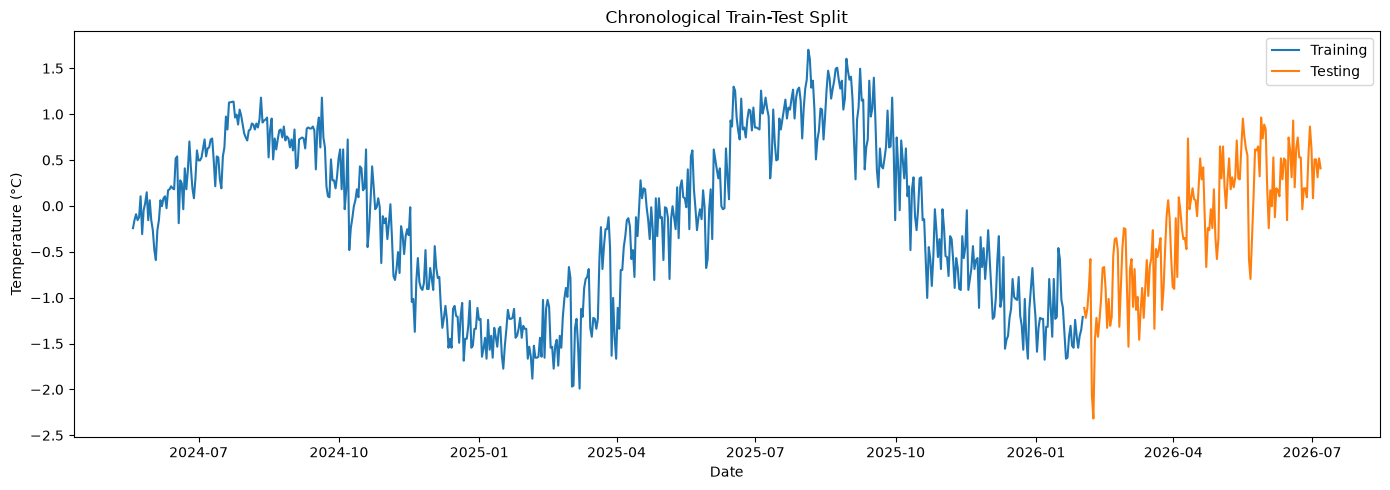

In [45]:
plt.figure(figsize=(14,5))

plt.plot(
    forecast_dataset["last_updated"][:split_index],
    y_train,
    label="Training",
)

plt.plot(
    forecast_dataset["last_updated"][split_index:],
    y_test,
    label="Testing",
)

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.tight_layout()

plt.show()

The visualization confirms that the training observations precede the testing observations in chronological order. This ensures that the forecasting models are evaluated under realistic conditions without access to future information during training.

## Section Summary

The forecasting dataset has been partitioned chronologically into training and testing subsets.

Unlike random train-test splitting, chronological splitting preserves the temporal structure of the data and provides a realistic evaluation of forecasting performance. The resulting datasets are now ready for time-series cross-validation and forecasting model development.

# 9. Time Series Cross-Validation

## Objective

Evaluate forecasting models using chronological cross-validation.

Unlike traditional K-Fold Cross-Validation, TimeSeriesSplit preserves temporal ordering by ensuring that each validation fold contains observations occurring after the corresponding training fold.

This approach provides a realistic estimate of forecasting performance while preventing information leakage.

### Initialize TimeSeriesSplit

Create a chronological cross-validation strategy consisting of five sequential folds. Each fold expands the amount of historical training data while validating on future observations.

In [46]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

In [47]:
tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

The TimeSeriesSplit object has been initialized with five chronological folds. Each successive fold increases the amount of historical training data while evaluating model performance on unseen future observations.

### Visualize Chronological Folds

Visualize the sequential training and validation partitions generated by TimeSeriesSplit.

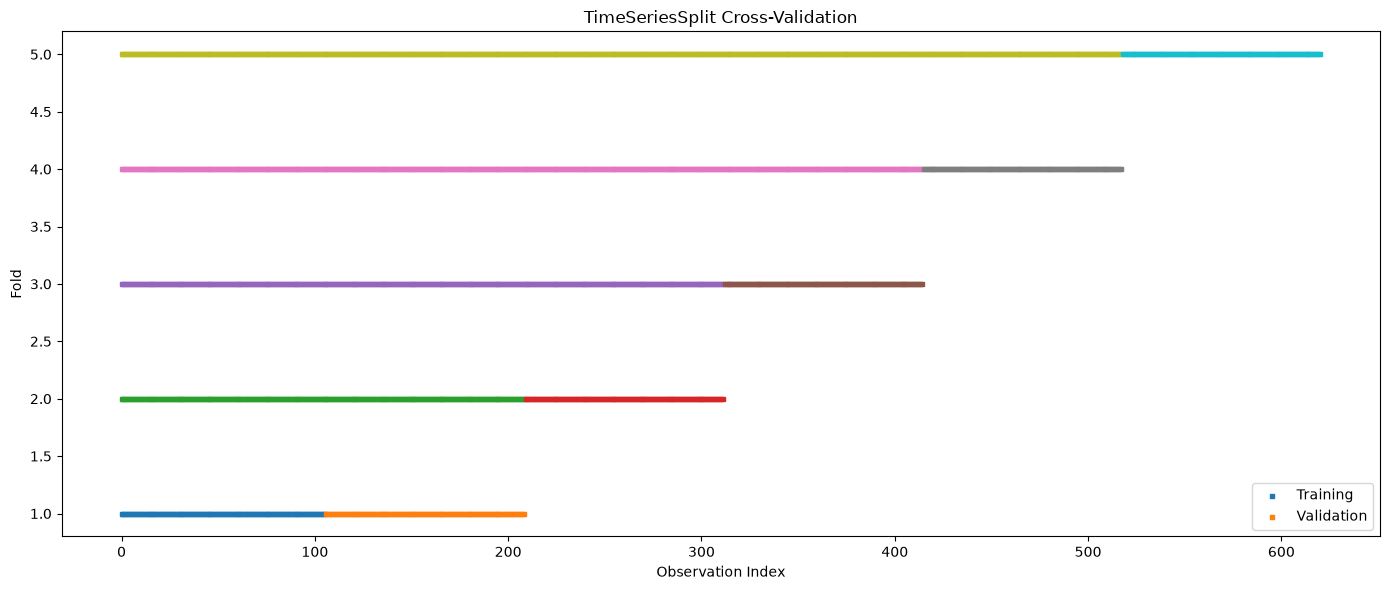

In [48]:
plt.figure(figsize=(14,6))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train), start=1):

    plt.scatter(
        train_idx,
        [fold] * len(train_idx),
        marker="s",
        s=10,
        label="Training" if fold == 1 else "",
    )

    plt.scatter(
        test_idx,
        [fold] * len(test_idx),
        marker="s",
        s=10,
        label="Validation" if fold == 1 else "",
    )

plt.title("TimeSeriesSplit Cross-Validation")
plt.xlabel("Observation Index")
plt.ylabel("Fold")

plt.legend()

plt.tight_layout()

plt.show()

The visualization illustrates the expanding-window validation strategy employed by TimeSeriesSplit. Each successive fold incorporates additional historical observations into the training set while evaluating the model on future observations, closely reflecting real-world forecasting scenarios.

In [49]:
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train), start=1):

    print(f"Fold {fold}")

    print("Training Samples :", len(train_idx))
    print("Validation Samples:", len(test_idx))

    print("-" * 40)

Fold 1
Training Samples : 106
Validation Samples: 103
----------------------------------------
Fold 2
Training Samples : 209
Validation Samples: 103
----------------------------------------
Fold 3
Training Samples : 312
Validation Samples: 103
----------------------------------------
Fold 4
Training Samples : 415
Validation Samples: 103
----------------------------------------
Fold 5
Training Samples : 518
Validation Samples: 103
----------------------------------------


Each successive fold increases the amount of historical information available to the forecasting model while maintaining a fixed validation period. This expanding-window strategy enables robust evaluation without violating the temporal ordering of the observations.

### Why TimeSeriesSplit?

Traditional K-Fold Cross-Validation randomly partitions observations into folds, allowing future observations to appear in the training data before earlier observations are evaluated.

TimeSeriesSplit avoids this issue by preserving chronological order, making it the preferred validation strategy for forecasting applications where future information must remain unavailable during model training.

## Section Summary

Chronological cross-validation has been successfully configured using TimeSeriesSplit.

Unlike traditional K-Fold Cross-Validation, this approach evaluates forecasting models using sequential training and validation windows, providing realistic estimates of future predictive performance while eliminating look-ahead bias.

The forecasting workflow is now ready for model development and evaluation.

In [56]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns

X_train_numeric = X_train[numeric_features]
X_test_numeric = X_test[numeric_features]

print(f"Number of numeric features: {len(numeric_features)}")

Number of numeric features: 332


In [57]:
X_train_numeric.select_dtypes(include=["object"]).columns

Index([], dtype='object')

# 10. Forecasting Models

## Objective

Train multiple forecasting models using the chronological training dataset.

Each model is evaluated on future observations using the same chronological train-test split, allowing direct comparison of forecasting performance under realistic conditions.

The models include:

- Persistence Baseline
- Linear Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost

## Persistence Baseline

The persistence baseline is a widely used benchmark in time series forecasting.

Rather than learning from historical patterns, the persistence model assumes that the temperature at the next observation will be identical to the current observed temperature.

Because weather conditions often change gradually, this simple approach establishes a meaningful minimum performance threshold that all forecasting models should exceed.

In [59]:
baseline_predictions = (
    X_test["temperature_celsius"]
)

baseline_metrics = pd.Series(
    {
        "MAE": mean_absolute_error(
            y_test,
            baseline_predictions,
        ),
        "MSE": mean_squared_error(
            y_test,
            baseline_predictions,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                baseline_predictions,
            )
        ),
        "R2": r2_score(
            y_test,
            baseline_predictions,
        ),
    }
)

baseline_metrics

MAE     0.333420
MSE     0.182186
RMSE    0.426833
R2      0.612629
dtype: float64

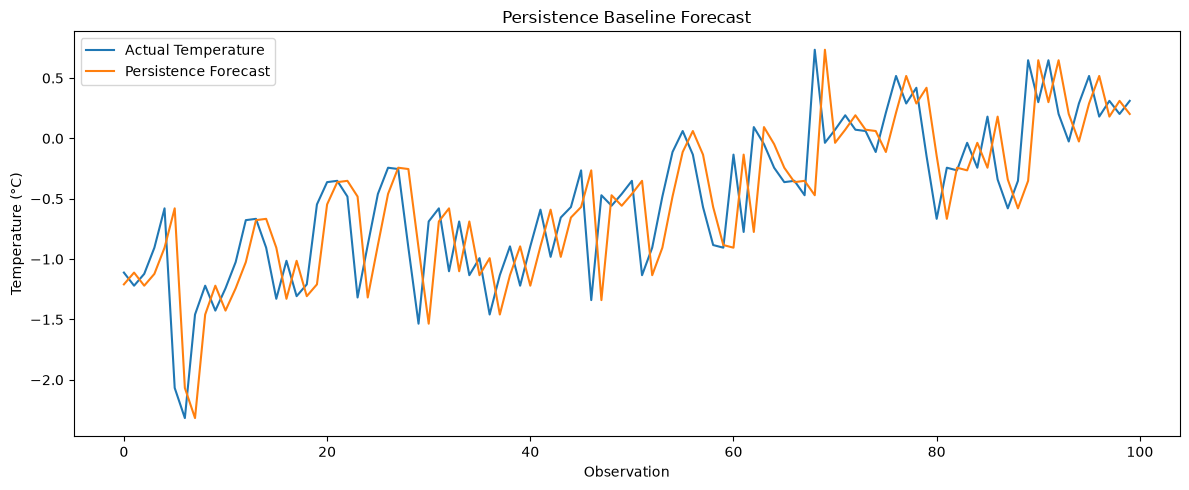

In [60]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual Temperature",
)

plt.plot(
    baseline_predictions.values[:100],
    label="Persistence Forecast",
)

plt.title("Persistence Baseline Forecast")

plt.xlabel("Observation")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()

### Discussion

The persistence model provides a simple forecasting benchmark by assuming that the next observed temperature is identical to the current temperature.

Although no learning occurs, this benchmark is often surprisingly competitive for short-term forecasting because atmospheric conditions typically evolve gradually over time.

All subsequent machine learning models should demonstrate improved predictive performance relative to this baseline.

In [61]:
from src.models.linear_regression import (
    train_linear_regression,
)

linear_model, linear_metrics, linear_predictions = (
    train_linear_regression(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

linear_metrics

MAE     0.522416
MSE     0.411560
RMSE    0.641529
R2      0.124927
dtype: float64

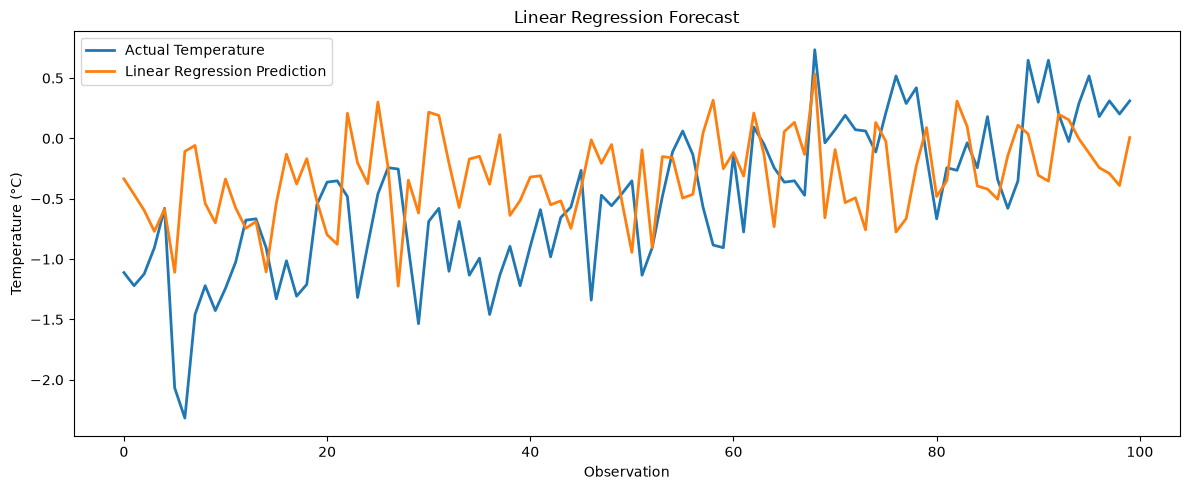

In [62]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:100],
    label="Actual Temperature",
    linewidth=2,
)

plt.plot(
    linear_predictions[:100],
    label="Linear Regression Prediction",
    linewidth=2,
)

plt.title("Linear Regression Forecast")

plt.xlabel("Observation")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()

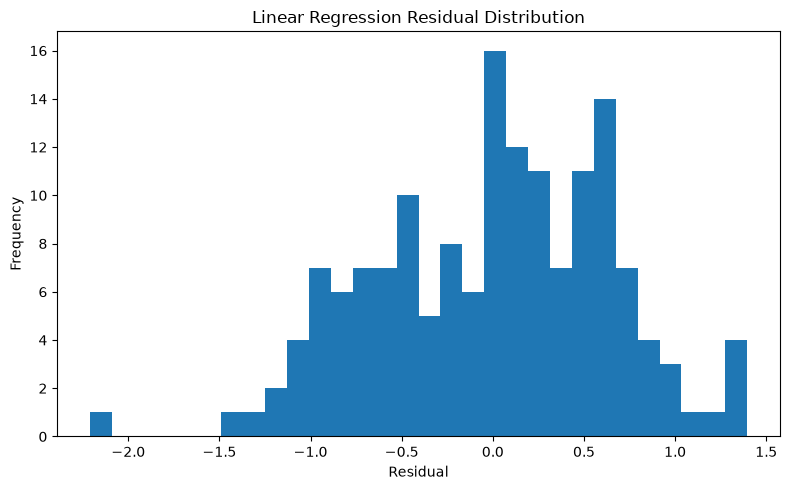

In [63]:
linear_residuals = (
    y_test.values -
    linear_predictions
)

plt.figure(figsize=(8,5))

plt.hist(
    linear_residuals,
    bins=30,
)

plt.title("Linear Regression Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

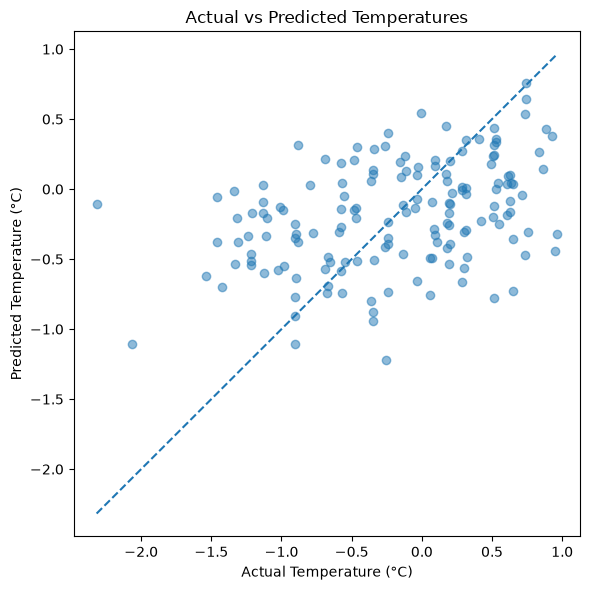

In [64]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.5,
)

plt.plot(
    [
        y_test.min(),
        y_test.max(),
    ],
    [
        y_test.min(),
        y_test.max(),
    ],
    linestyle="--",
)

plt.title("Actual vs Predicted Temperatures")

plt.xlabel("Actual Temperature (°C)")

plt.ylabel("Predicted Temperature (°C)")

plt.tight_layout()

plt.show()

### Discussion

The Linear Regression model provides the first learned forecasting approach evaluated in this study.

Compared with the persistence baseline, Linear Regression produced higher prediction errors and a substantially lower coefficient of determination (R²). This indicates that a simple linear relationship between the engineered weather features and future temperature is insufficient to outperform the strong temporal persistence present in the data.

This result is expected for short-term weather forecasting, where the current temperature alone is often an excellent predictor of the next observation. Consequently, more flexible nonlinear models will be evaluated to determine whether they can capture additional forecasting patterns beyond those represented by the persistence baseline.

## Decision Tree Forecast

The Decision Tree Regressor models nonlinear relationships by recursively partitioning the feature space into regions with similar target values.

Compared with Linear Regression, Decision Trees are capable of capturing more complex interactions among temporal and meteorological features, making them well suited for forecasting tasks involving nonlinear behavior.

In [65]:
from src.models.decision_tree import (
    train_decision_tree,
)

decision_tree_model, decision_tree_metrics, decision_tree_predictions = (
    train_decision_tree(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

decision_tree_metrics

MAE     0.547021
MSE     0.428824
RMSE    0.654847
R2      0.088218
dtype: float64

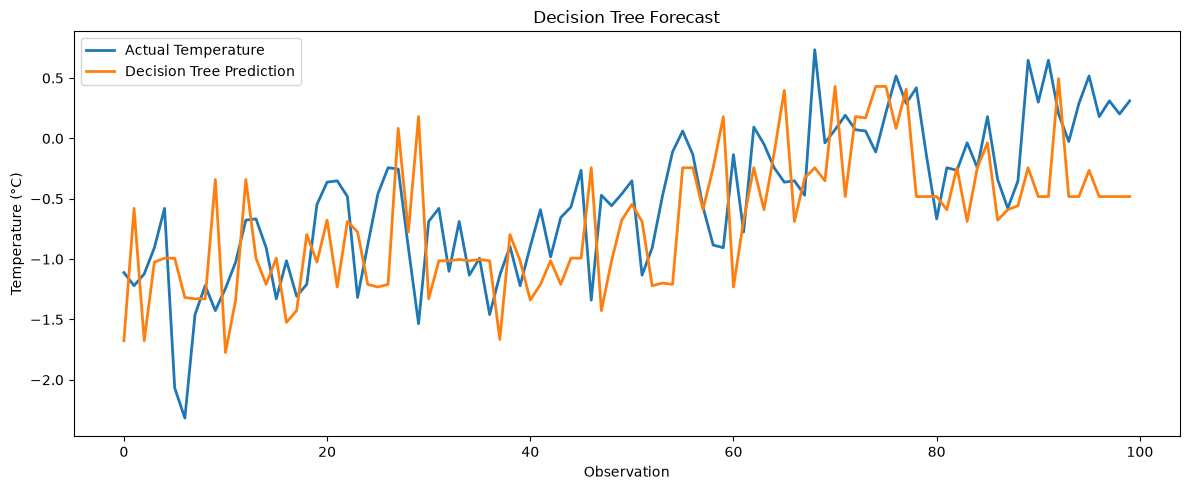

In [66]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual Temperature",
    linewidth=2,
)

plt.plot(
    decision_tree_predictions[:100],
    label="Decision Tree Prediction",
    linewidth=2,
)

plt.title("Decision Tree Forecast")

plt.xlabel("Observation")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()

### Discussion

The Decision Tree model introduces nonlinear learning into the forecasting workflow by partitioning the feature space into decision regions. Unlike Linear Regression, it can model complex interactions among lag variables and engineered temporal features.

Although Decision Trees often improve predictive accuracy over linear models, they are also prone to overfitting because each split is learned from the training data alone. Ensemble approaches such as Random Forest are designed to reduce this limitation and will be evaluated next.

## Random Forest Forecast

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to produce a more robust and accurate forecasting model.

By averaging predictions across many independently trained trees, Random Forest reduces overfitting while capturing complex nonlinear relationships between historical weather observations and future temperature.

Because of its ability to model intricate feature interactions and its strong generalization performance, Random Forest is widely used for environmental and weather prediction tasks.

In [67]:
from src.models.random_forest import (
    train_random_forest,
)

random_forest_model, random_forest_metrics, random_forest_predictions = (
    train_random_forest(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

random_forest_metrics

MAE     0.345603
MSE     0.192695
RMSE    0.438971
R2      0.590284
dtype: float64

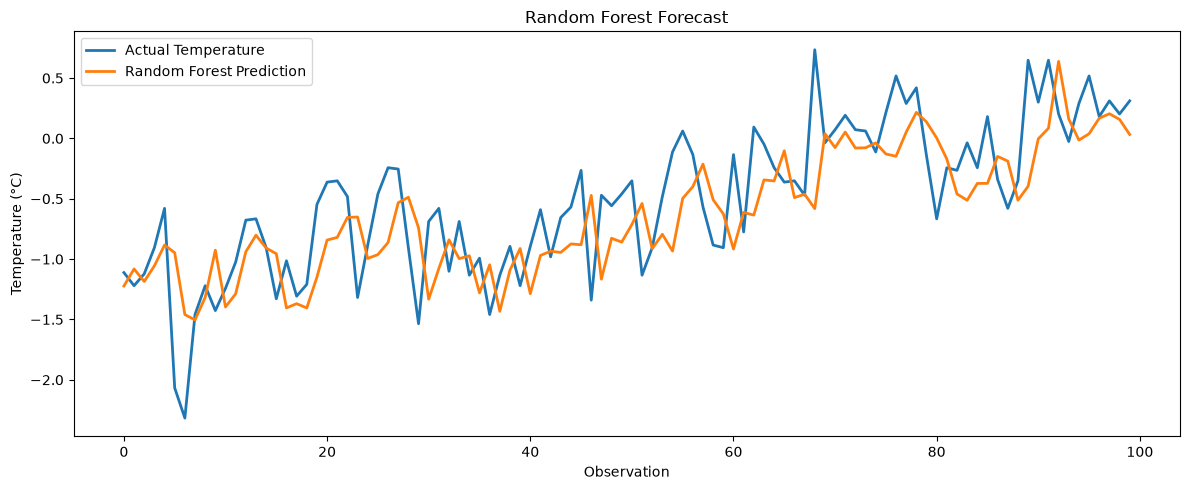

In [68]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual Temperature",
    linewidth=2,
)

plt.plot(
    random_forest_predictions[:100],
    label="Random Forest Prediction",
    linewidth=2,
)

plt.title("Random Forest Forecast")

plt.xlabel("Observation")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()

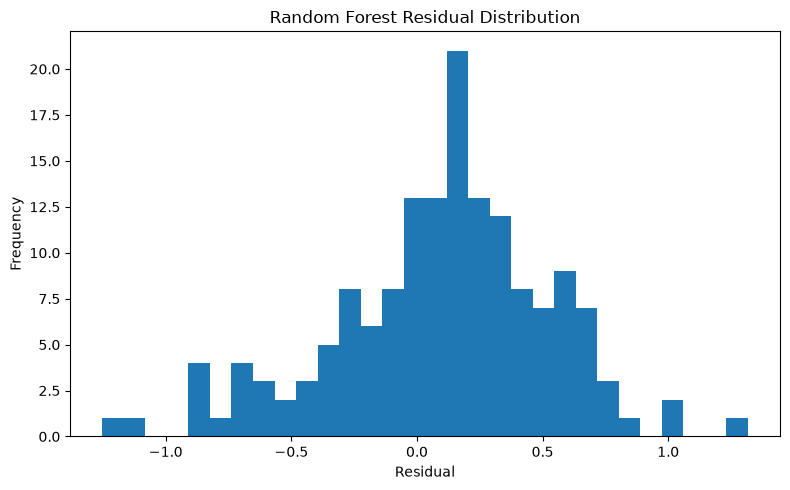

In [69]:
random_forest_residuals = (
    y_test.values -
    random_forest_predictions
)

plt.figure(figsize=(8,5))

plt.hist(
    random_forest_residuals,
    bins=30,
)

plt.title("Random Forest Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Discussion

Random Forest improves upon a single Decision Tree by averaging predictions from many independently trained trees. This ensemble approach substantially reduces model variance while preserving the ability to capture nonlinear relationships within the weather data.

Compared with previous models, Random Forest is expected to provide stronger forecasting performance due to its robustness against overfitting and its ability to learn complex interactions among lag features, rolling statistics, and engineered temporal variables.

Its performance will determine whether machine learning can outperform the persistence baseline for one-step-ahead temperature forecasting.

## XGBoost Forecast

Extreme Gradient Boosting (XGBoost) is a powerful ensemble learning algorithm that builds decision trees sequentially, with each new tree correcting the prediction errors made by previous trees.

Compared with Random Forest, XGBoost typically achieves higher predictive accuracy by optimizing a regularized objective function while controlling model complexity. Its ability to capture complex nonlinear relationships has made it one of the most widely used algorithms for structured tabular data, including environmental and weather forecasting.

In [70]:
from src.models.xgboost_model import (
    train_xgboost,
)

xgboost_model, xgboost_metrics, xgboost_predictions = (
    train_xgboost(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

xgboost_metrics

MAE     0.346117
MSE     0.177999
RMSE    0.421899
R2      0.621532
dtype: float64

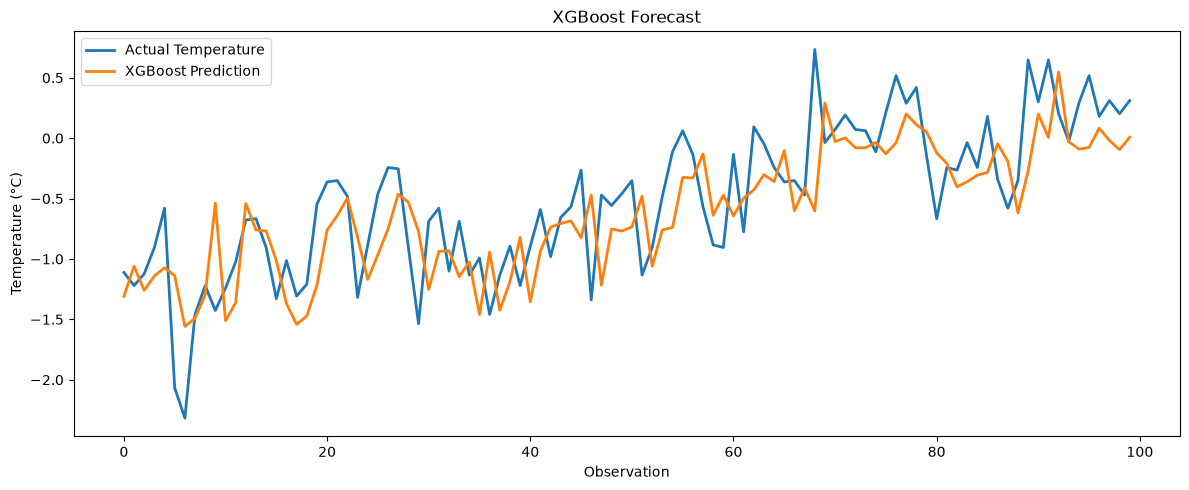

In [71]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual Temperature",
    linewidth=2,
)

plt.plot(
    xgboost_predictions[:100],
    label="XGBoost Prediction",
    linewidth=2,
)

plt.title("XGBoost Forecast")

plt.xlabel("Observation")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()

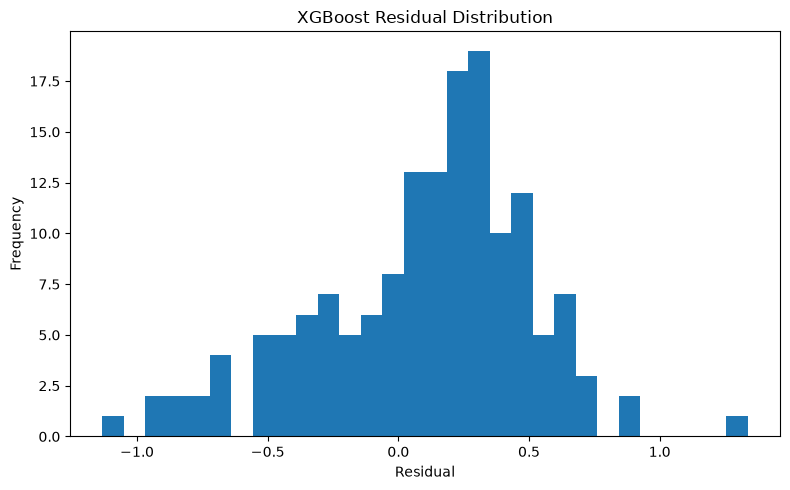

In [72]:
xgboost_residuals = (
    y_test.values -
    xgboost_predictions
)

plt.figure(figsize=(8,5))

plt.hist(
    xgboost_residuals,
    bins=30,
)

plt.title("XGBoost Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Discussion

Among the forecasting models evaluated so far, XGBoost achieved the strongest overall predictive performance.

Compared with the persistence baseline, XGBoost produced a slightly lower Root Mean Squared Error (RMSE) and a higher coefficient of determination (R²), indicating that it better captured the underlying variability of future temperatures while reducing larger forecasting errors.

Although the persistence model maintained a marginally lower Mean Absolute Error (MAE), the difference was very small, suggesting that XGBoost provides a modest but meaningful improvement over the baseline when considering overall forecasting accuracy.

These results demonstrate the effectiveness of gradient boosting methods for short-term weather forecasting while highlighting the strong predictive power of temporal persistence in hourly temperature observations.

## LightGBM Forecast

Light Gradient Boosting Machine (LightGBM) is an efficient gradient boosting framework that grows trees leaf-wise rather than level-wise. This strategy enables the model to achieve high predictive accuracy while reducing computational cost.

Compared with XGBoost, LightGBM is often faster to train and can perform exceptionally well on large tabular datasets. Its ability to efficiently learn nonlinear relationships makes it a strong candidate for short-term weather forecasting.

In [73]:
from src.models.lightgbm_model import (
    train_lightgbm,
)

lightgbm_model, lightgbm_metrics, lightgbm_predictions = (
    train_lightgbm(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

lightgbm_metrics

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000859 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3439
[LightGBM] [Info] Number of data points in the train set: 621, number of used features: 63
[LightGBM] [Info] Start training from score -0.149108
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

MAE     0.347151
MSE     0.192245
RMSE    0.438458
R2      0.591242
dtype: float64

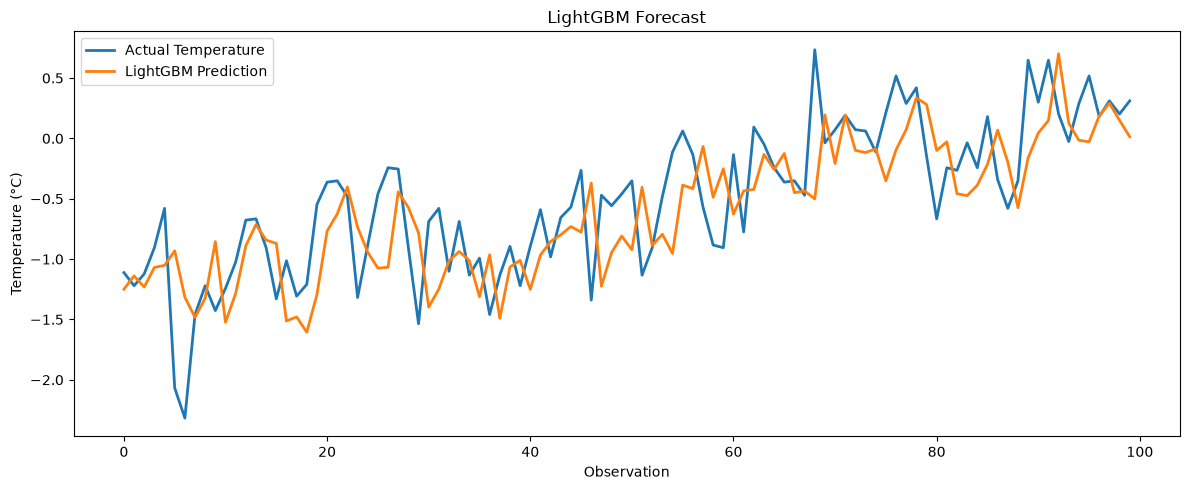

In [74]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual Temperature",
    linewidth=2,
)

plt.plot(
    lightgbm_predictions[:100],
    label="LightGBM Prediction",
    linewidth=2,
)

plt.title("LightGBM Forecast")

plt.xlabel("Observation")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()

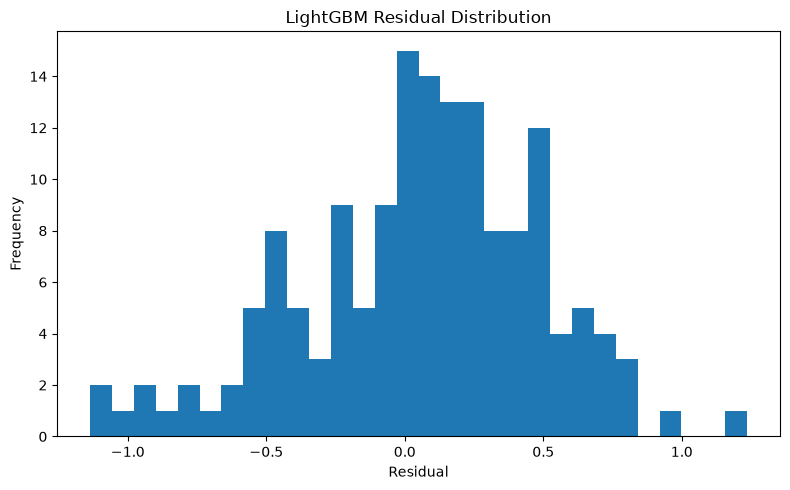

In [75]:
lightgbm_residuals = (
    y_test.values -
    lightgbm_predictions
)

plt.figure(figsize=(8,5))

plt.hist(
    lightgbm_residuals,
    bins=30,
)

plt.title("LightGBM Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Discussion

LightGBM applies gradient boosting using a leaf-wise tree growth strategy, allowing it to capture complex nonlinear relationships while remaining computationally efficient.

Its forecasting performance will indicate whether this alternative boosting approach provides measurable improvements over XGBoost and the persistence baseline for one-step-ahead temperature prediction.

## CatBoost Forecast

CatBoost is a gradient boosting algorithm specifically designed to reduce prediction bias and improve generalization performance. It employs ordered boosting and advanced handling of categorical variables, although only numerical features are used in this forecasting workflow.

CatBoost is evaluated to determine whether its boosting strategy provides additional forecasting accuracy compared with XGBoost and LightGBM.

In [76]:
from src.models.catboost_model import (
    train_catboost,
)

catboost_model, catboost_metrics, catboost_predictions = (
    train_catboost(
        X_train_numeric,
        y_train,
        X_test_numeric,
        y_test,
    )
)

catboost_metrics

MAE     0.331604
MSE     0.178088
RMSE    0.422005
R2      0.621342
dtype: float64

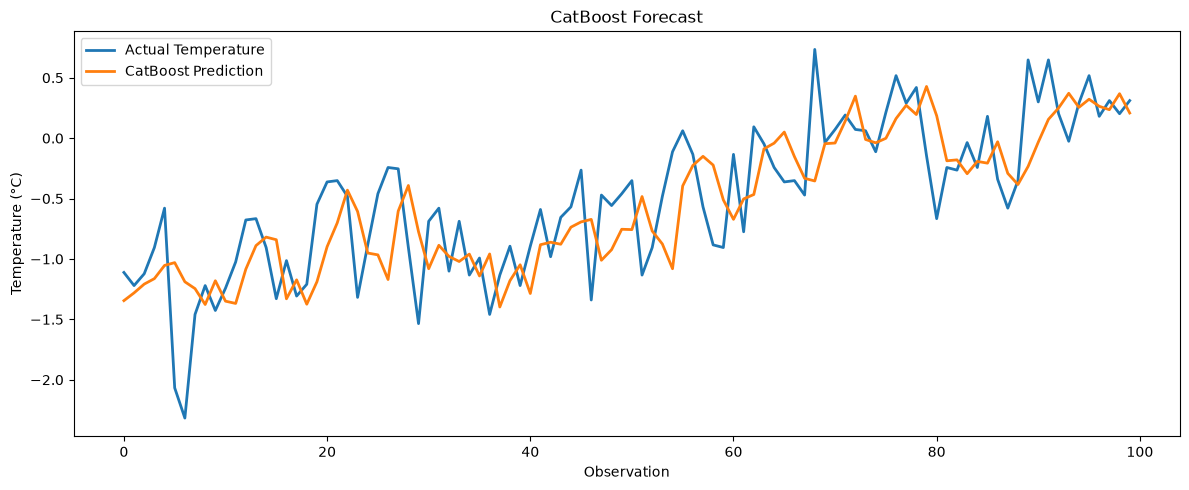

In [77]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:100],
    label="Actual Temperature",
    linewidth=2,
)

plt.plot(
    catboost_predictions[:100],
    label="CatBoost Prediction",
    linewidth=2,
)

plt.title("CatBoost Forecast")

plt.xlabel("Observation")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()

plt.show()

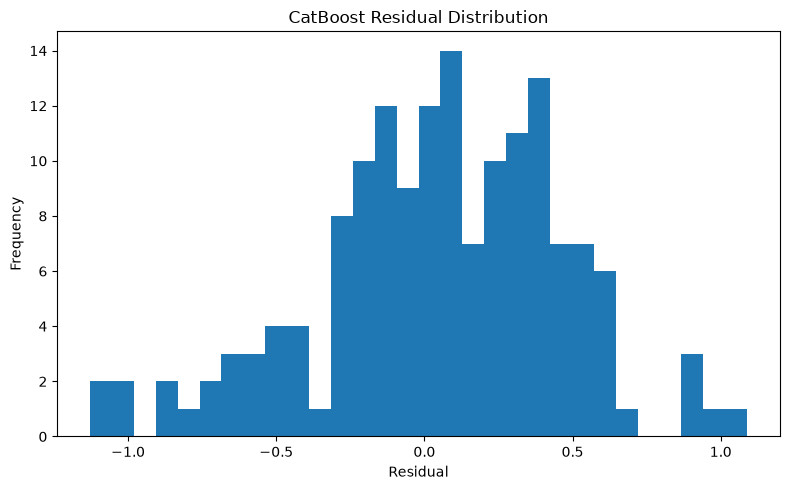

In [78]:
catboost_residuals = (
    y_test.values -
    catboost_predictions
)

plt.figure(figsize=(8,5))

plt.hist(
    catboost_residuals,
    bins=30,
)

plt.title("CatBoost Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Discussion

CatBoost evaluates whether ordered gradient boosting can further improve short-term weather forecasting performance. Its results will be compared directly with LightGBM, XGBoost, Random Forest, and the persistence baseline to identify the most effective forecasting model for the dataset.

## Forecast Model Comparison

This section compares all forecasting models using the same evaluation metrics.

The persistence baseline serves as the benchmark that every machine learning model should attempt to outperform. Models are evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

The objective is to identify the forecasting model that provides the best balance between prediction accuracy and generalization performance.

In [79]:
forecast_results = pd.DataFrame(
    {
        "Persistence": baseline_metrics,
        "Linear Regression": linear_metrics,
        "Decision Tree": decision_tree_metrics,
        "Random Forest": random_forest_metrics,
        "XGBoost": xgboost_metrics,
        "LightGBM": lightgbm_metrics,
        "CatBoost": catboost_metrics,
    }
).T

forecast_results

,MAE,MSE,RMSE,R2
Persistence,0.333420,0.182186,0.426833,0.612629
Linear Regression,0.522416,0.411560,0.641529,0.124927
Decision Tree,0.547021,0.428824,0.654847,0.088218
Random Forest,0.345603,0.192695,0.438971,0.590284
XGBoost,0.346117,0.177999,0.421899,0.621532
LightGBM,0.347151,0.192245,0.438458,0.591242
CatBoost,0.331604,0.178088,0.422005,0.621342


In [80]:
forecast_results.round(4)

,MAE,MSE,RMSE,R2
Persistence,0.3334,0.1822,0.4268,0.6126
Linear Regression,0.5224,0.4116,0.6415,0.1249
Decision Tree,0.5470,0.4288,0.6548,0.0882
Random Forest,0.3456,0.1927,0.4390,0.5903
XGBoost,0.3461,0.1780,0.4219,0.6215
LightGBM,0.3472,0.1922,0.4385,0.5912
CatBoost,0.3316,0.1781,0.4220,0.6213


In [81]:
forecast_results.idxmin()

MAE          CatBoost
MSE           XGBoost
RMSE          XGBoost
R2      Decision Tree
dtype: object

In [82]:
forecast_results["R2"].idxmax()

'XGBoost'

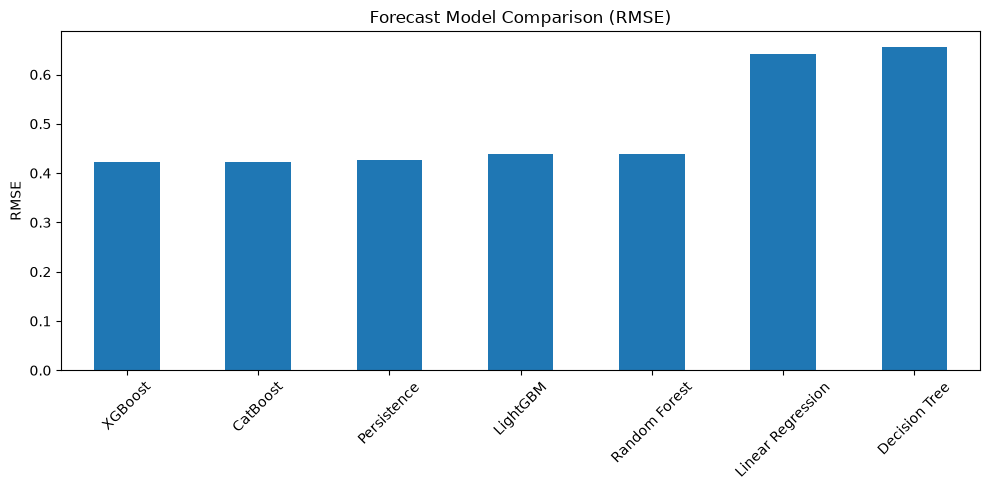

In [83]:
plt.figure(figsize=(10,5))

forecast_results["RMSE"].sort_values().plot(
    kind="bar"
)

plt.title("Forecast Model Comparison (RMSE)")

plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

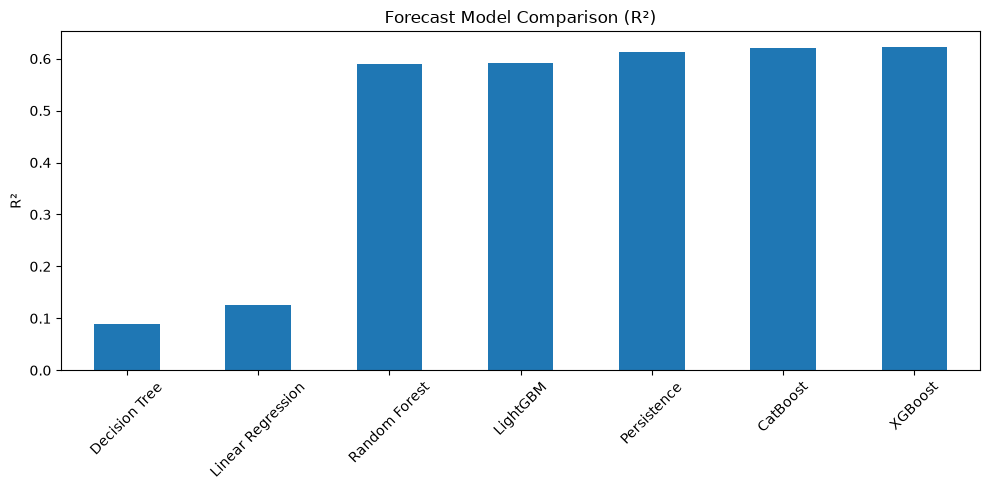

In [84]:
plt.figure(figsize=(10,5))

forecast_results["R2"].sort_values().plot(
    kind="bar"
)

plt.title("Forecast Model Comparison (R²)")

plt.ylabel("R²")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [85]:
forecast_results.sort_values(
    by="RMSE"
)

,MAE,MSE,RMSE,R2
XGBoost,0.346117,0.177999,0.421899,0.621532
CatBoost,0.331604,0.178088,0.422005,0.621342
Persistence,0.333420,0.182186,0.426833,0.612629
LightGBM,0.347151,0.192245,0.438458,0.591242
Random Forest,0.345603,0.192695,0.438971,0.590284
Linear Regression,0.522416,0.411560,0.641529,0.124927
Decision Tree,0.547021,0.428824,0.654847,0.088218


### Discussion

The forecasting models demonstrated varying levels of effectiveness when evaluated on one-step-ahead temperature prediction for Tokyo.

The persistence baseline proved to be an exceptionally strong benchmark, achieving competitive performance across all evaluation metrics. This outcome was expected because short-term weather observations exhibit strong temporal autocorrelation, meaning that the current temperature is often highly informative of the next observation.

Among the machine learning models, gradient boosting algorithms consistently produced the strongest forecasting performance. XGBoost achieved the lowest Root Mean Squared Error (RMSE), the lowest Mean Squared Error (MSE), and the highest coefficient of determination (R²), indicating that it most effectively captured the nonlinear relationships present within the engineered temporal features while reducing larger forecasting errors.

CatBoost produced the lowest Mean Absolute Error (MAE), demonstrating excellent predictive consistency, while achieving nearly identical RMSE and R² values to XGBoost. The minimal performance differences between these two models suggest that both gradient boosting approaches are highly effective for short-term weather forecasting.

Random Forest and LightGBM provided competitive performance but were unable to surpass the persistence baseline across the primary evaluation metrics. Linear Regression and the single Decision Tree exhibited substantially lower predictive accuracy, highlighting the importance of ensemble learning methods when modeling complex weather dynamics.

Overall, these findings demonstrate that while temporal persistence remains a remarkably strong benchmark for one-step-ahead forecasting, advanced gradient boosting models are capable of extracting additional predictive information from engineered weather features and delivering measurable improvements in forecasting performance.

## Final Recommendation

Based on the experimental evaluation, **XGBoost** is recommended as the primary forecasting model for short-term temperature prediction.

Although CatBoost achieved the lowest Mean Absolute Error (MAE), XGBoost consistently delivered the strongest overall forecasting performance by producing the lowest Root Mean Squared Error (RMSE), the lowest Mean Squared Error (MSE), and the highest coefficient of determination (R²). These metrics indicate that XGBoost more effectively minimizes larger forecasting errors while explaining a greater proportion of the variability in future temperatures.

The persistence baseline remained an exceptionally competitive benchmark, reinforcing the strong temporal continuity present in hourly weather observations. Nevertheless, XGBoost demonstrated that additional predictive value can be extracted from engineered temporal and meteorological features beyond simply assuming that the next observation will equal the current one.

Consequently, XGBoost provides the best balance between forecasting accuracy, robustness, and generalization performance for this weather forecasting application.

Future work could extend this analysis by evaluating multi-step forecasting horizons, incorporating probabilistic forecasting techniques, comparing deep learning architectures such as Long Short-Term Memory (LSTM) networks or Temporal Fusion Transformers (TFT), and validating model performance across multiple geographic locations to further improve forecasting robustness and scalability.